# Milan Mobile Network Traffic Forecasting

**Author:** Michael Nwuju

We will be doing some Internet activity forecasting with these three models - a plain RNN, an LSTM, and a GRU.

The data covers 1 November 2013 to 1 January 2014. The models are evaluated on the week of 16 to 22 December 2013.

In order to progress, simply execute each cell sequentially.

Before beginning, set the runtime to a GPU: click Runtime, then Change runtime type, then select T4 GPU under the hardware accelerator. Google Colab often does this for you already.


## 1. Environment

In [17]:
import torch
import subprocess, sys, os

nvidia_command = ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"]

print(subprocess.run(nvidia_command, capture_output=True,  text=True). stdout.strip()  or "no GPU, using CPU")

print("Torch", torch.__version__, "and Cuda available:", torch.cuda.is_available())

Tesla T4, 15360 MiB
Torch 2.11.0+cu128 and Cuda available: True


### Getting the project code onto Colab

This notebook has the narrative only. To not crowd the notebook, I implemented a modular code design which can be pulled into Google Colab to be used.

All the functions it calls are in src/ in the GitHub repo so the runtime requires a copy of that code to run any function.

The repo is public and cloning it takes no credentials.

In [18]:
REPO_DIRECTORY = "/content/time-series-forecasting"

REPO_URL = "https://github.com/michael-alu/time-series-forecasting.git"

if os.path.isdir(os.path.join(REPO_DIRECTORY, ".git")):
    subprocess.run(["git", "-C", REPO_DIRECTORY, "pull", "--quiet"], check=True)
else:
    subprocess.run(["git", "clone", "--quiet", REPO_URL, REPO_DIRECTORY], check=True)

SRC = os.path.join(REPO_DIRECTORY, "src")

# Adds the src/ folder from GitHub into the Google Colab file system
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f"Code ready at {SRC}")

Code ready at /content/time-series-forecasting/src


One of the tricky things about Python is that it caches imported modules, so doing a new commit part way through a session doesn't make a difference to any code you've already imported.

This helper drops the project modules from the cache and reimports them, avoiding a need to restart the runtime every time you change code.

Run after any `git pull`.

In [19]:
import importlib

PROJECT_MODULES = ["config", "dataset", "models", "train", "evaluate", "tune", "eda", "spatial", "diagnostics"]


def reload_project():
    for name in PROJECT_MODULES:
        sys.modules.pop(name, None)

    return {
        name: importlib.import_module(name) for name in PROJECT_MODULES
    }


reload_project()

print("Project modules loaded")

Project modules loaded


In [20]:
!pip install -q statsmodels==0.14.4 pyarrow

print("Dependencies ready")

Dependencies ready


## 2. Data


In [21]:
!pip install -q gdown

import pathlib

import gdown

# File ids from the shared folder 1XryzRR6RDJI1xPR4pWKU1GJJMpDwrl9e.
# Fetching each file by id rather than the whole folder, because the folder also
# holds results from previous runs that this notebook is about to regenerate.
DATA_FILE_IDS = {
    "internet_matrix.npy": "1C0gFDSMMy9Sx9esD6lhS1nKOdRz0SXo5",
    "matrix_index.npz": "1zEVTO0UHLpYqtfw8ZYSkGg9aiYsAHpsh",
    "square_totals.parquet": "1k3qsriY8TDDYWsRE0yQD1SiDCwFsawYO",
    "focus_squares.parquet": "1bhS5zHGIt-vp5Ins-t34nMUBJMVMdzeH",
}

LOCAL_DATA = pathlib.Path("/content/data")

LOCAL_DATA.mkdir(parents=True, exist_ok=True)

for name, file_id in DATA_FILE_IDS.items():
    target = LOCAL_DATA / name

    if not target.exists():
        gdown.download(id=file_id, output=str(target), quiet=True)

    print(f"{name:<24} {target.stat().st_size / 1e6:>8.1f} MB")


internet_matrix.npy         357.1 MB
matrix_index.npz              0.1 MB
square_totals.parquet         0.3 MB
focus_squares.parquet         0.4 MB


Files land on the runtime's own disk rather than a network mount, so memory mapping
the 357 MB matrix stays fast.


In [22]:
import dataset

dataset.set_data_dir(LOCAL_DATA)

matrix, index, square_ids = dataset.load_matrix()

print("Matrix", matrix.shape, matrix.dtype)

print("\nFrom", index[0], "to", index[-1])

print("\nAreas by total Internet traffic:", dataset.top_squares(3))

Matrix (8928, 10000) float32

From 2013-11-01 00:00:00+01:00 to 2014-01-01 23:50:00+01:00

Areas by total Internet traffic: [5161, 5059, 5259]


## 3. Exploratory analysis

Each analysis function saves its figure to `results/figures` and returns the numbers
behind it. That way the plots in this notebook are exactly the files that go into the
report, rather than a second version drawn separately.

In [23]:
import eda
import config
import pandas as pd
from IPython.display import Image, display


pd.set_option("display.width", 170)

def show(figure_name: str) -> None:
    display(Image(filename=str(config.FIGURE_DIRECTORY / figure_name)))

### How traffic is spread across the 10,000 areas

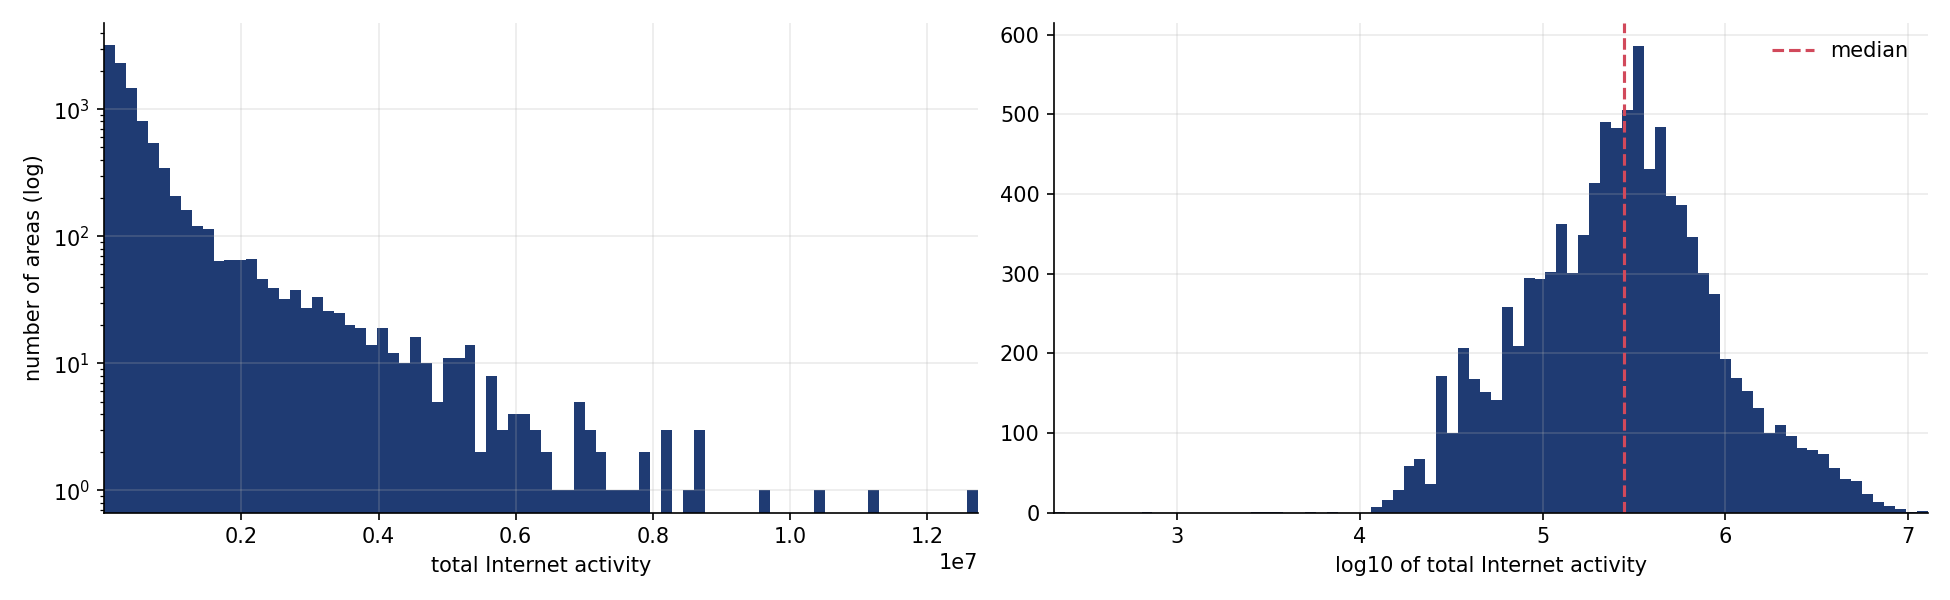

,value
max,1.274007e+07
areas,1.000000e+04
mean,5.552894e+05
median,2.778714e+05
skew,4.265382e+00
max_over_median,4.584879e+01
share_held_by_top_100,1.104921e-01
share_held_by_top_1000,4.838854e-01


In [24]:
totals = dataset.load_square_totals()

spread = eda.traffic_spread(totals)

show("eda_traffic_distribution.png")

spread.to_frame("value")

### First two weeks, the three busiest areas plus 4159 and 4556

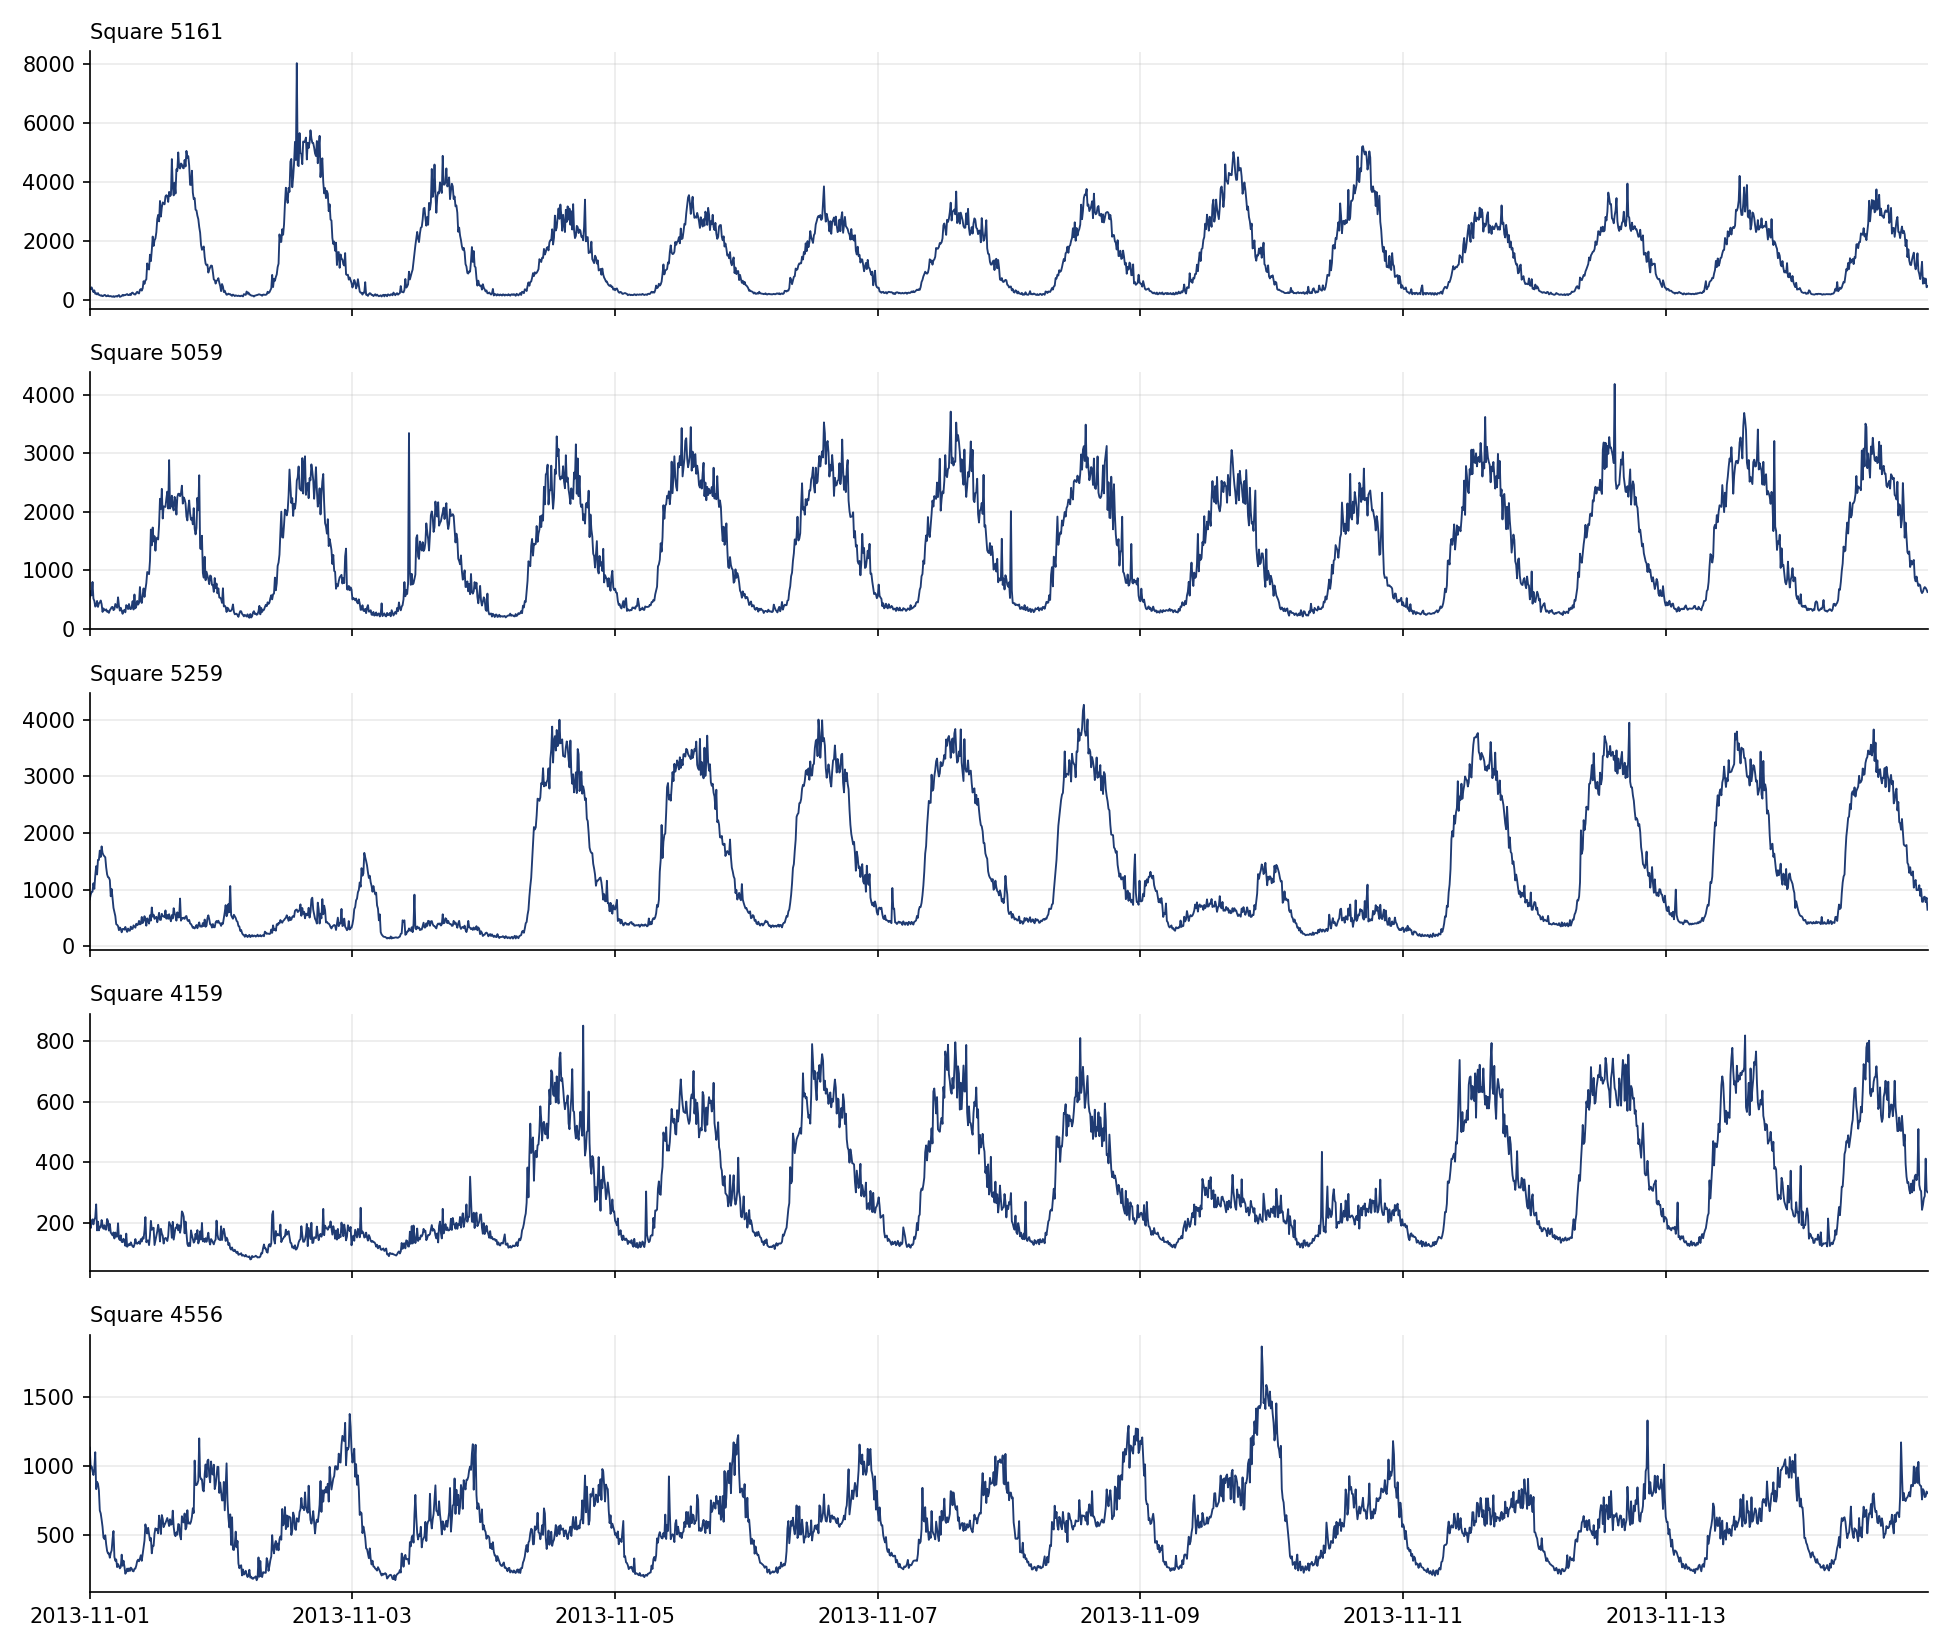

,peak,mean,square_id,peak_over_trough,weekend_vs_weekday,busiest_hour
0,8044.07,1483.550049,5161,76.70,1.26,16
1,4182.75,1330.619995,5059,22.12,0.77,14
2,4262.90,1293.500000,5259,31.70,0.34,13
3,851.05,311.350006,4159,10.60,0.52,12
4,1868.74,592.700012,4556,10.87,1.11,22


In [25]:
comparison = eda.compare_areas()

show("eda_focus_series.png")

comparison

### A closer look at the busiest area

In [26]:
busiest = dataset.load_series(dataset.top_squares(1)[0])

eda.autocorrelation(busiest).to_frame("value")

,value
lag_6_one_hour,0.9388
lag_1_ten_minutes,0.9871
lag_144_one_day,0.8783
lag_288_two_days,0.7696


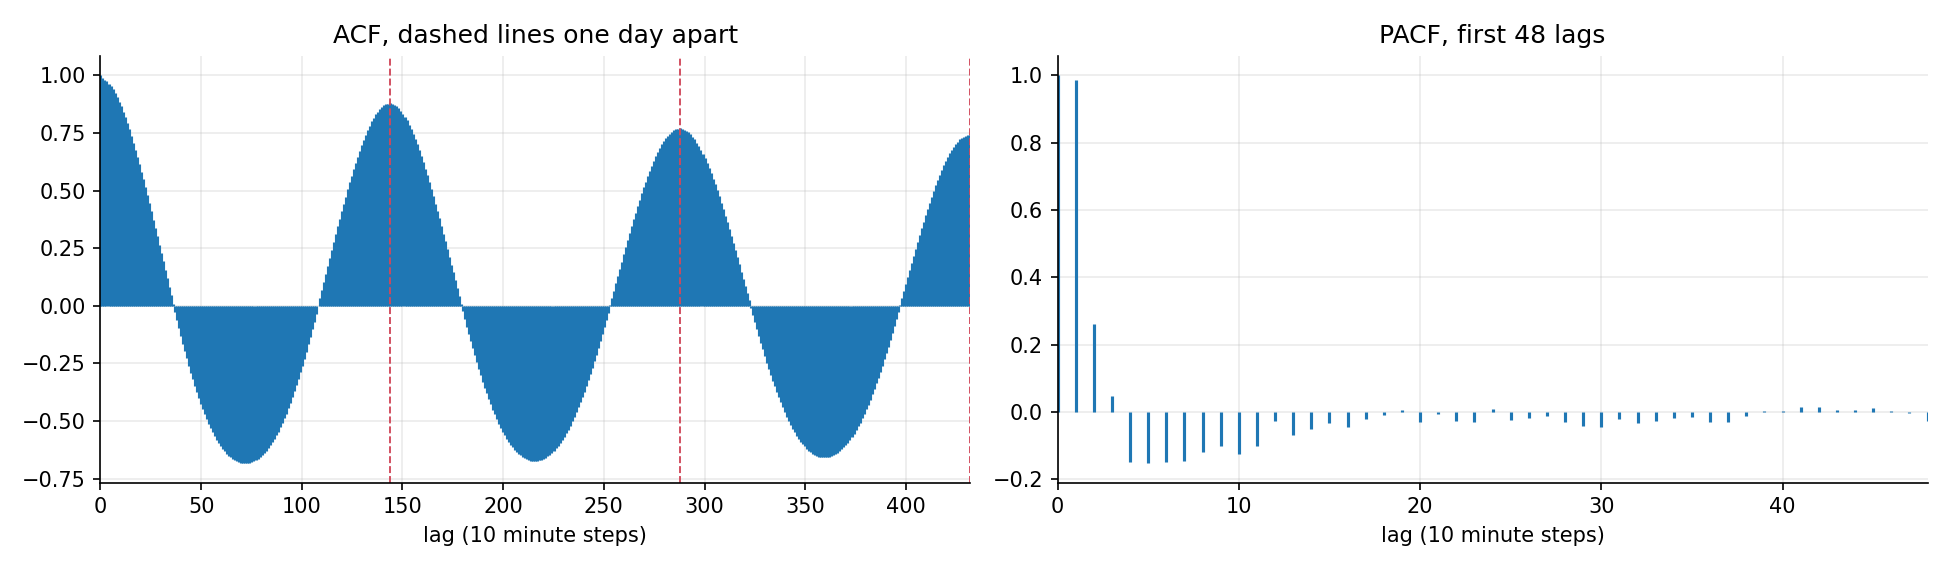

In [27]:
show("eda_autocorrelation.png")

In [28]:
eda.decompose(busiest).to_frame("share of variance")

,share of variance
share_daily_pattern,0.7744
share_trend,0.0307
share_leftover,0.1364


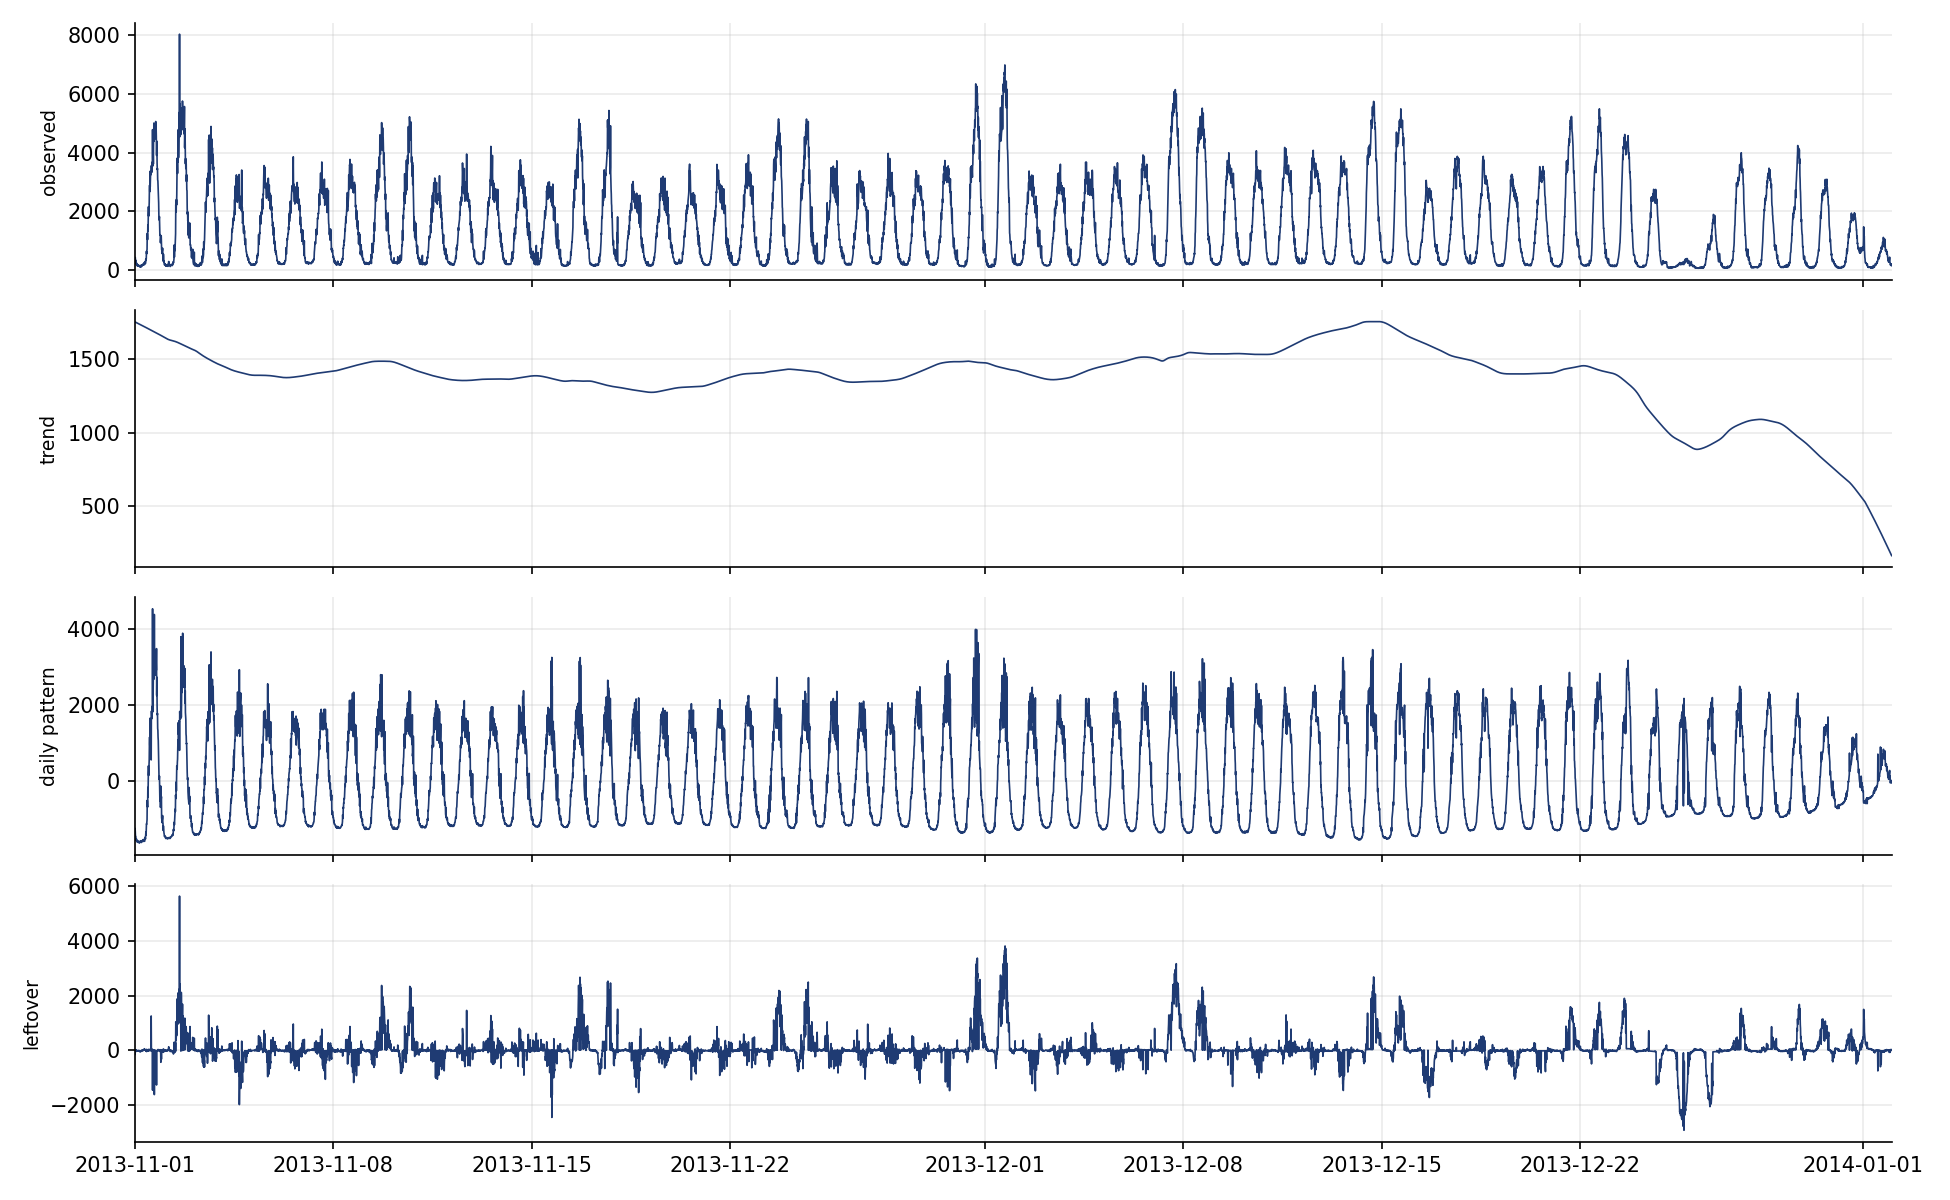

In [29]:
show("eda_decomposition.png")

In [30]:
eda.stationarity(busiest)

/content/time-series-forecasting/src/eda.py:223: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(data)[1]
/content/time-series-forecasting/src/eda.py:223: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(data)[1]
/content/time-series-forecasting/src/eda.py:223: FutureWarning: adfuller currently returns a plain tuple whose length depends on the

,series,ADF_p,ADF_says_stable,KPSS_p,KPSS_says_stable
0,raw,0.0,True,> 0.1,True
1,difference,0.0,True,> 0.1,True
2,day over day difference,0.0,True,> 0.1,True


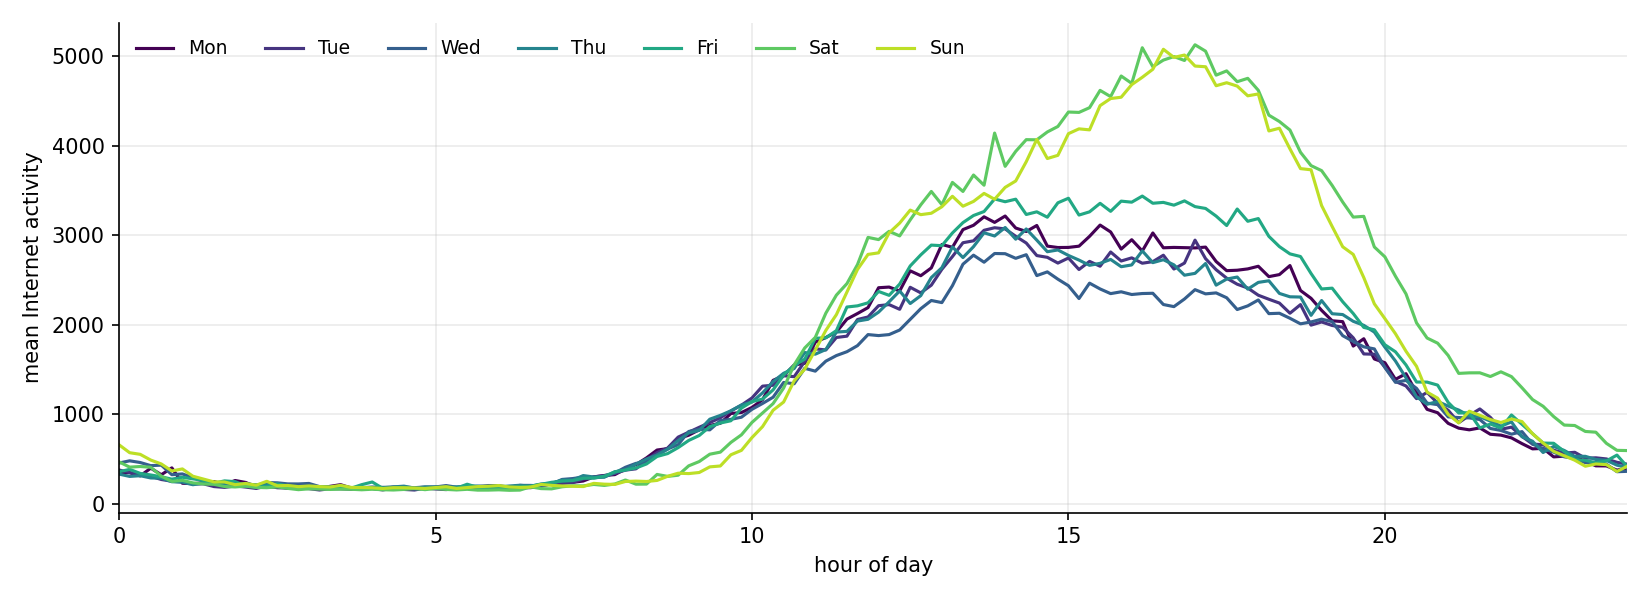

In [31]:
eda.daily_shape(busiest)

show("eda_weekly_profile.png")

### Where the traffic is

The 10,000 areas are 100 by 100 blocks over Milan, so these totals can be turned back into an image and read like a map.

This is important for the comparison later - if neighbouring areas are similar in behaviour, the three areas we forecast are not three independent problems.

In [32]:
import spatial

totals = dataset.load_square_totals()

grid = spatial.totals_grid(totals)

for square_id in dataset.top_squares(3) + config.EXTRA_SQUARES:
    row, col = spatial.square_to_cell(square_id)

    rank = int(totals.index[totals["square_id"] == square_id][0]) + 1

    print(f"Square {square_id:>5}  Row {row:>3}  Column {col:>3}   Rank {rank:>5} of 10000")

print(f"\nMoran's I: {spatial.morans_i(grid):.3f}  (0 would be random, 1 one smooth blob)")

Square  5161  Row  51  Column  60   Rank     1 of 10000
Square  5059  Row  50  Column  58   Rank     2 of 10000
Square  5259  Row  52  Column  58   Rank     3 of 10000
Square  4159  Row  41  Column  58   Rank   424 of 10000
Square  4556  Row  45  Column  55   Rank   109 of 10000

Moran's I: 0.905  (0 would be random, 1 one smooth blob)


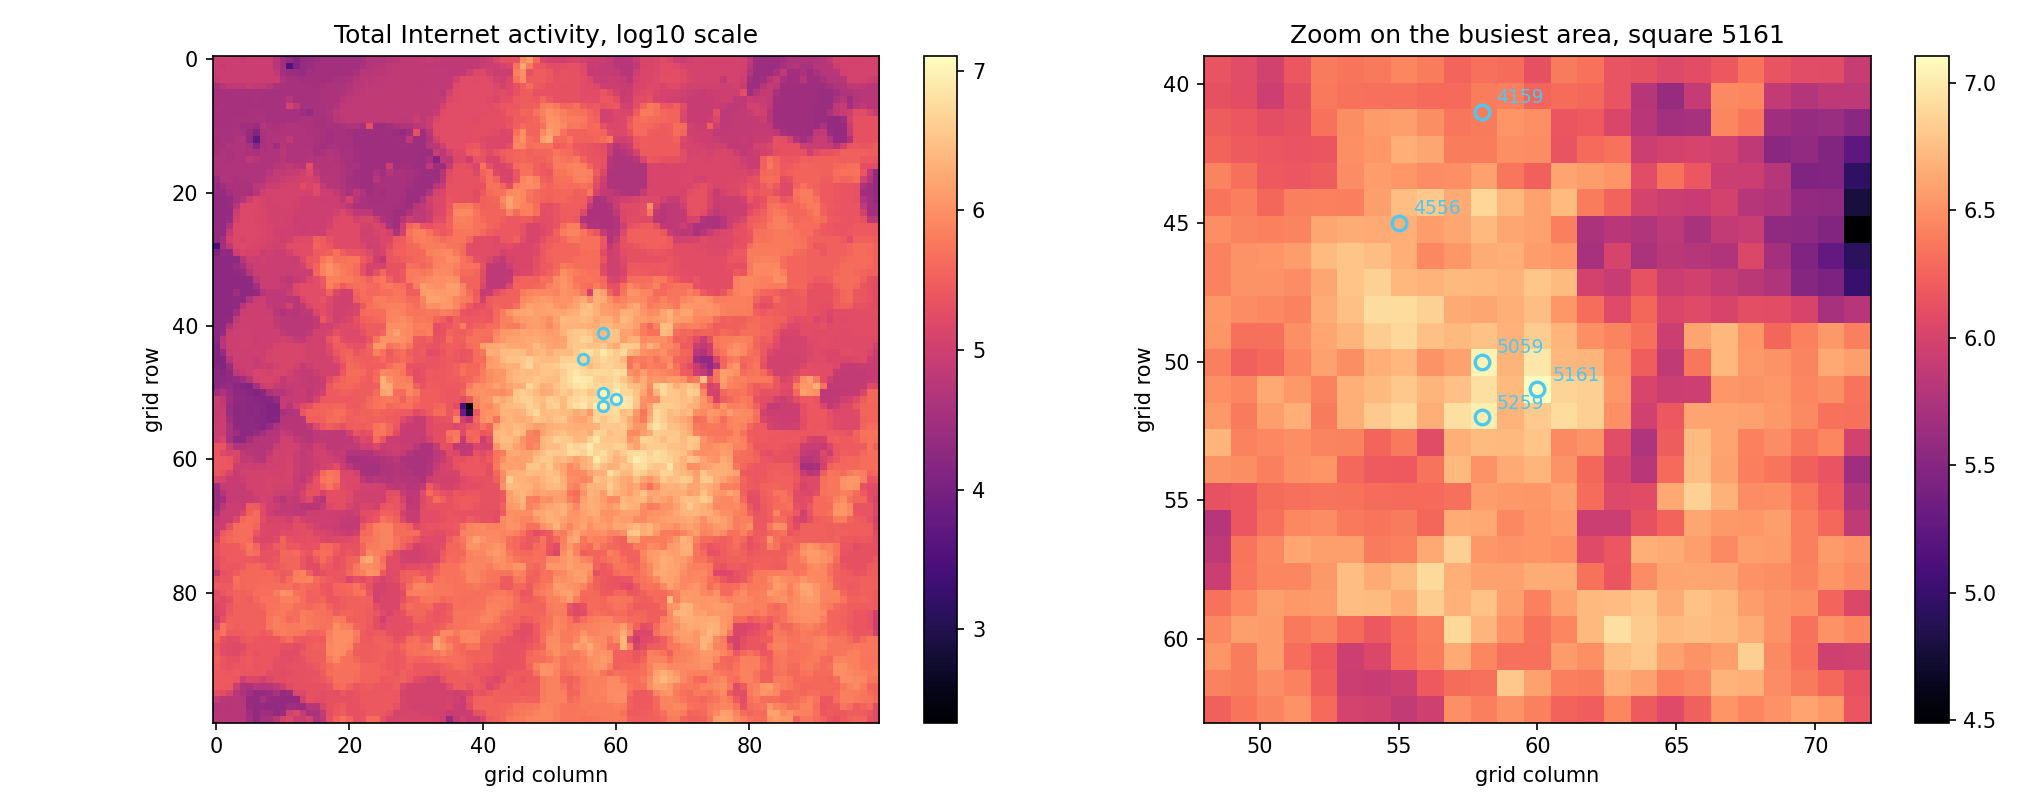

In [33]:
spatial.draw_map(grid, dataset.top_squares(3) + config.EXTRA_SQUARES)

show("eda_spatial_map.png")

Does that similarity fade with distance?


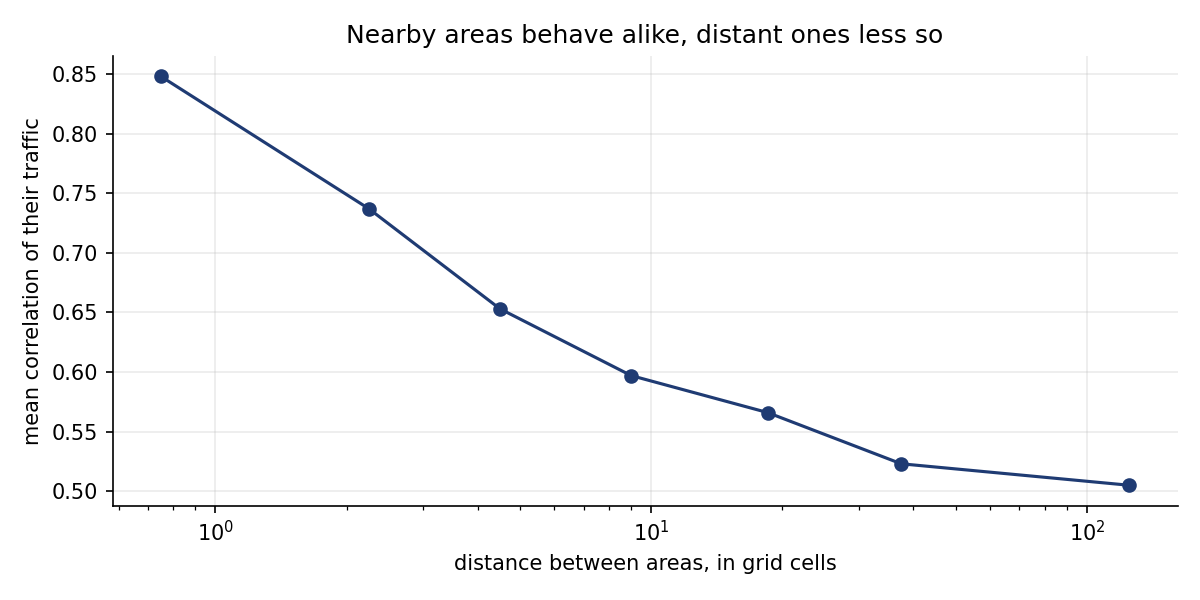

,mean,count
distance in cells,,
"(0.0, 1.5]",0.848,100
"(1.5, 3.0]",0.737,205
"(3.0, 6.0]",0.653,770
"(6.0, 12.0]",0.597,2481
"(12.0, 25.0]",0.566,8462
"(25.0, 50.0]",0.523,14132
"(50.0, 200.0]",0.505,4975


In [34]:
decay = spatial.correlation_against_distance()

spatial.draw_correlation_decay(decay)

show("eda_spatial_correlation.png")

decay

## 4. Forecasting setup

The split is chronological and fixed by the assignment at the test end:

| split | period | intervals |
|---|---|---|
| train | 1 Nov to 8 Dec | 5472 |
| validation | 9 to 15 Dec | 1008 |
| test | 16 to 22 Dec | 1008 |

Each row is a window of the previous `sequence_length` values with the target value being the next one. Scaling is fitted on the training period only.

The windows for the validation and test weeks are permitted to extend back into days before those weeks, which is fair in this context as the one step ahead forecasts truly has seen those values by the time it needs to predict.

In [35]:
series = dataset.load_series(dataset.top_squares(1)[0])

train = series.loc[: config.TRAIN_END]

val = series.loc[config.VAL_START : config.VAL_END]

test = series.loc[config.TEST_START : config.TEST_END]

datasets = [("train", train), ("val", val), ("test", test)]

for name, part in datasets:
    print(f"{name:6s} {len(part):>5}  {part.index[0]} -> {part.index[-1]}")

prepared = dataset.build_dataset(series, sequence_length=144, scaling="Standard")

for split, _ in datasets:
    print(f"{split:6s} X {prepared[f'X_{split}'].shape}  y {prepared[f'y_{split}'].shape}")

train   5472  2013-11-01 00:00:00+01:00 -> 2013-12-08 23:50:00+01:00
val     1008  2013-12-09 00:00:00+01:00 -> 2013-12-15 23:50:00+01:00
test    1008  2013-12-16 00:00:00+01:00 -> 2013-12-22 23:50:00+01:00
train  X (5328, 144, 1)  y (5328,)
val    X (1008, 144, 1)  y (1008,)
test   X (1008, 144, 1)  y (1008,)


In [36]:
import models

ARCHITECTURES = ["RNN", "LSTM", "GRU"]

for architecture in ARCHITECTURES:
    model = models.build_model(architecture, hidden_size=64, num_layers=1)

    print(f"{architecture:5s} {model.parameter_count():>7,} parameters")

RNN     4,353 parameters
LSTM   17,217 parameters
GRU    12,929 parameters


## 5. Hyperparameter search

The process is staged and not out of a huge grid with each subsequent stage being justified by the stage before.

The search runs on the busiest area and each candidate is scored on the validation week. The test week is never used here.

This is the slow cell, around 45 training runs in total on a T4.

In [37]:
import tune
import json
import train

device = train.pick_device()

train.warm_up(device)

hardware = train.describe_hardware(device)

print(json.dumps(hardware, indent=2))

{
  "device": "cuda",
  "torch": "2.11.0+cu128",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "gpu": "Tesla T4"
}


In [38]:
chosen = {}

tables = {}


for architecture in ARCHITECTURES:
    best, table = tune.search(series, architecture, device=device, verbose=True)

    chosen[architecture] = best

    tables[architecture] = table


[RNN] tuning sequence_length
  {'sequence_length': 12}                          val MAE    107.12  <- best so far
  {'sequence_length': 36}                          val MAE    109.03
  {'sequence_length': 72}                          val MAE    106.68  <- best so far
  {'sequence_length': 144}                         val MAE    109.06

[RNN] tuning scaling
  {'scaling': 'Standard'}                          val MAE    106.68
  {'scaling': 'MinMax'}                            val MAE    119.03
  {'scaling': 'LogStandard'}                       val MAE    107.70

[RNN] tuning capacity
  {'hidden_size': 16}                              val MAE    105.92  <- best so far
  {'hidden_size': 32}                              val MAE    110.69
  {'hidden_size': 64}                              val MAE    106.68
  {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2} val MAE    105.84  <- best so far

[RNN] tuning optimisation
  {'learning_rate': 0.003}                         val MAE    107.70
  

In [39]:
all_runs = pd.concat(tables.values(), ignore_index=True)

all_runs[
    [
        "cell",
        "stage",
        "tried",
        "sequence_length",
        "hidden_size",
        "num_layers",
        "learning_rate",
        "batch_size",
        "scaling",
        "val_MAE",
        "val_RMSE",
        "parameters",
        "epochs_run",
        "train_seconds",
        "kept"
    ]
].round(3)

,cell,stage,tried,sequence_length,hidden_size,num_layers,learning_rate,batch_size,scaling,val_MAE,val_RMSE,parameters,epochs_run,train_seconds,kept
0,RNN,sequence_length,{'sequence_length': 12},12,64,1,0.001,64,Standard,107.118,160.375,4353,21,5.7,True
1,RNN,sequence_length,{'sequence_length': 36},36,64,1,0.001,64,Standard,109.025,156.369,4353,43,11.2,False
2,RNN,sequence_length,{'sequence_length': 72},72,64,1,0.001,64,Standard,106.681,156.674,4353,30,8.1,True
3,RNN,sequence_length,{'sequence_length': 144},144,64,1,0.001,64,Standard,109.063,159.754,4353,21,5.2,False
4,RNN,scaling,{'scaling': 'Standard'},72,64,1,0.001,64,Standard,106.681,156.674,4353,30,7.9,False
5,RNN,scaling,{'scaling': 'MinMax'},72,64,1,0.001,64,MinMax,119.032,163.000,4353,28,7.1,False
6,RNN,scaling,{'scaling': 'LogStandard'},72,64,1,0.001,64,LogStandard,107.697,166.477,4353,17,4.5,False
7,RNN,capacity,{'hidden_size': 16},72,16,1,0.001,64,Standard,105.925,158.470,321,28,7.0,True
8,RNN,capacity,{'hidden_size': 32},72,32,1,0.001,64,Standard,110.685,158.062,1153,40,10.3,False
9,RNN,capacity,{'hidden_size': 64},72,64,1,0.001,64,Standard,106.681,156.674,4353,30,7.9,False


In [40]:
for cell, chosen_config in chosen.items():
    print(f"{cell:5s} {chosen_config.label()}")

RNN   RNN_seq72_h64_Standard
LSTM  LSTM_seq144_h64_LogStandard
GRU   GRU_seq36_h64_Standard


## 6. Final models on the test week

The configuration chosen for each model is retrained from scratch on each of the
three busiest areas. Tuning per area would make a difference between areas
impossible to attribute to the data rather than to the hyperparameters.

In [41]:
import numpy as np
import evaluate

squares = dataset.top_squares(3)

metric_tables = {}

timing_rows= []

prediction_frames = []

for square_id in squares:
    scores = {}

    area_series = dataset.load_series(square_id)

    for architecture in ARCHITECTURES:
        print(f"\n[Square {square_id}] {architecture}")

        outcome = tune.final_fit(area_series, chosen[architecture], device=device, verbose=False)

        trained = outcome["trained"]

        scores[architecture] = outcome["scores"]

        timing_rows.append({
            "model": architecture,
            "square_id": square_id,
            "parameters": trained.parameters,
            "epochs_run": trained.epochs_run,
            "best_epoch": trained.best_epoch,
            "train_seconds": round(trained.train_seconds, 2),
            "sequence_length": trained.config.sequence_length,
            "inference_seconds_1008": round(outcome["predict_seconds"], 4),
            "seconds_per_epoch": round(trained.train_seconds / trained.epochs_run, 3),
        })

        prediction_frames.append(pd.DataFrame({
            "model": architecture,
            "square_id": square_id,
            "actual": outcome["actual"],
            "timestamp": outcome["index"],
            "predicted": outcome["predicted"],
        }))

        print(f"  Mean Absolute Error {outcome['scores']['mean_absolute_error']:.2f}")
        print(f"\n  Root Mean Squared Error {outcome['scores']['root_mean_squared_error']:.2f}")

    test_index = prediction_frames[-1]["timestamp"]

    actual = prediction_frames[-1]["actual"].to_numpy()

    # Two naive baselines. Seasonal naive repeats the value from the same time
    # yesterday. Persistence repeats the most recent observation, which is the one
    # that matters here, because traffic correlates 0.987 with its value ten minutes
    # ago. Any model has to beat persistence to be worth implementing.

    persistence_model = ("Persistence", models.persistence(area_series, pd.DatetimeIndex(test_index)))

    seasonal_naive_model = ("SeasonalNaive", models.seasonal_naive(area_series, pd.DatetimeIndex(test_index)))

    baseline_models = [persistence_model, seasonal_naive_model]

    for name, values in baseline_models:
        scores[name] = evaluate.score(actual, values)

        prediction_frames.append(pd.DataFrame({
            "model": name,
            "actual": actual,
            "predicted": values,
            "square_id": square_id,
            "timestamp": test_index,
        }))

    metric_tables[square_id] = evaluate.metrics_table(scores)

predictions = pd.concat(prediction_frames, ignore_index=True)

timings = pd.DataFrame(timing_rows)


[Square 5161] RNN
  Mean Absolute Error 85.95

  Root Mean Squared Error 126.31

[Square 5161] LSTM
  Mean Absolute Error 82.64

  Root Mean Squared Error 125.57

[Square 5161] GRU
  Mean Absolute Error 83.39

  Root Mean Squared Error 122.86

[Square 5059] RNN
  Mean Absolute Error 74.93

  Root Mean Squared Error 106.07

[Square 5059] LSTM
  Mean Absolute Error 70.33

  Root Mean Squared Error 102.41

[Square 5059] GRU
  Mean Absolute Error 70.11

  Root Mean Squared Error 100.97

[Square 5259] RNN
  Mean Absolute Error 71.08

  Root Mean Squared Error 97.39

[Square 5259] LSTM
  Mean Absolute Error 67.50

  Root Mean Squared Error 97.77

[Square 5259] GRU
  Mean Absolute Error 67.41

  Root Mean Squared Error 93.97


In [42]:
for square_id, table in metric_tables.items():
    print(f"\n{'=' * 10} Square {square_id} {'=' * 10}")

    print(table.to_string())


========== Square 5161 ==========
               mean_absolute_error  root_mean_squared_error  mean_absolute_percentage_error  mean_absolute_percentage_error_skipped
model                                                                                                                              
LSTM                        82.639                  125.573                           8.009                                     0.0
GRU                         83.388                  122.858                           9.249                                     0.0
RNN                         85.951                  126.312                           9.180                                     0.0
Persistence                 92.802                  134.878                           9.194                                     0.0
SeasonalNaive              338.594                  619.040                          25.940                                     0.0

========== Square 5059 ==========
      

In [43]:
timings

,model,square_id,parameters,epochs_run,best_epoch,train_seconds,sequence_length,inference_seconds_1008,seconds_per_epoch
0,RNN,5161,12673,28,20,8.20,72,0.0078,0.293
1,LSTM,5161,17217,29,21,8.50,144,0.0129,0.293
2,GRU,5161,12929,45,37,12.06,36,0.0068,0.268
3,RNN,5059,12673,19,11,5.15,72,0.0069,0.271
4,LSTM,5059,17217,19,11,5.77,144,0.0106,0.303
5,GRU,5059,12929,37,29,9.44,36,0.0066,0.255
6,RNN,5259,12673,19,11,5.85,72,0.0095,0.308
7,LSTM,5259,17217,28,20,7.58,144,0.0122,0.271
8,GRU,5259,12929,43,35,11.21,36,0.0068,0.261


### How much of the difference between models is real?

These tables are all from a single seed, however, while tuning we found a hidden size of 32 to give about 4.7 worse mean absolute error on each model than sizes 16 and 64.

This is not explained by any architectural consideration and is roughly 5 mean absolute error for the run to run noise.

As this is greater than the difference between the models, one seed does not give statistically significant evidence for the ranking.

Therefore each model is trained on five seeds. Each model is now compared on the same five seeds (pairing off the seeds) rather than noise in two averages.

In [44]:
from dataclasses import replace

SEEDS = [0, 1, 2, 3, 4]

seed_rows = []

for square_id in squares:
    area_series = dataset.load_series(square_id)

    for architecture in ARCHITECTURES:
        for seed in SEEDS:
            outcome = tune.final_fit(area_series, replace(chosen[architecture], seed=seed), device=device, verbose=False)

            seed_rows.append({
                "seed": seed,
                "model": architecture,
                "square_id": square_id,
                "train_seconds": round(outcome["trained"].train_seconds, 2),
                "mean_absolute_error": outcome["scores"]["mean_absolute_error"],
                "root_mean_squared_error": outcome["scores"]["root_mean_squared_error"],
                "mean_absolute_percentage_error": outcome["scores"]["mean_absolute_percentage_error"],
            })

    print(f"\nSquare {square_id} done")

seed_runs = pd.DataFrame(seed_rows)

seed_runs.head()


Square 5161 done

Square 5059 done

Square 5259 done


,seed,model,square_id,train_seconds,mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error
0,0,RNN,5161,5.45,86.845,131.456,8.183
1,1,RNN,5161,4.07,88.331,131.508,9.485
2,2,RNN,5161,10.40,83.088,124.192,8.683
3,3,RNN,5161,5.33,87.168,132.180,8.621
4,4,RNN,5161,6.06,84.949,130.111,8.481


Mean and standard deviation over the five seeds. The spread is the number that matters.

In [45]:
statistical_measures = ["mean", "std"]

statistical_errors = ["mean_absolute_error", "root_mean_squared_error"]

stability = seed_runs.groupby(["square_id", "model"])[statistical_errors].agg(statistical_measures).round(2)

stability

mean_absolute_error       root_mean_squared_error      
                               mean   std                    mean   std
square_id model                                                        
5059      GRU                 69.12  1.35                   98.73  1.54
          LSTM                67.57  1.43                   98.51  2.30
          RNN                 73.96  3.32                  102.25  4.02
5161      GRU                 83.70  2.72                  123.68  2.98
          LSTM                84.58  3.02                  128.74  4.76
          RNN                 86.08  2.07                  129.89  3.27
5259      GRU                 67.33  1.25                   95.27  1.46
          LSTM                66.00  1.24                   95.33  1.56
          RNN                 66.67  2.01                   95.66  2.93

### Paired comparison

Both models for a particular seed are trained in the same way in each geographical region so that the effect of the seed does not have any bearing.

An effect that has the same sign for all 15 pairs would be a real effect, whereas a change of sign would be simply noise.

In [46]:
wide = seed_runs.pivot_table(index=["square_id", "seed"], columns="model", values="mean_absolute_error")

pairs = pd.DataFrame({
    "GRU minus RNN": wide["GRU"] - wide["RNN"],
    "GRU minus LSTM": wide["GRU"] - wide["LSTM"],
    "LSTM minus RNN": wide["LSTM"] - wide["RNN"],
}).round(2)

# Where all pairs of models show the same directions, the signs will not change. "times negative" gives the number of pairs in support of the first model.
# Only if it is none or all of the pairs do the models agree on the sign.
# "out of" keeps the same meaning in each row, therefore the first number is the total number.
def consistent(df: pd.DataFrame) -> pd.Series:
    total_pairs = df["out of"].iloc[0]

    return df["times negative"].isin([0, total_pairs])

summary = pd.DataFrame({
    "out of": len(pairs),
    "times negative": (pairs < 0).sum(),
    "mean difference": pairs.mean().round(2),
}).assign(consistent=consistent)

print(summary.to_string())

print("\nNegative means the first model had the lower error")

pairs

                out of  times negative  mean difference  consistent
GRU minus RNN       15              10            -2.19       False
GRU minus LSTM      15               5             0.66       False
LSTM minus RNN      15              11            -2.85       False

Negative means the first model had the lower error


GRU minus RNN  GRU minus LSTM  LSTM minus RNN
square_id seed                                               
5059      0             -1.89            3.74           -5.63
          1             -8.86            3.84          -12.70
          2             -6.17           -0.53           -5.64
          3              0.20            0.10            0.10
          4             -7.50            0.57           -8.06
5161      0             -1.43            0.86           -2.28
          1             -2.02           -2.22            0.20
          2              0.42            3.35           -2.93
          3             -3.18           -1.66           -1.51
          4             -5.69           -4.76           -0.93
5259      0             -1.73           -2.79            1.06
          1              4.22            3.00            1.22
          2             -1.63            3.17           -4.80
          3              1.21            1.37           -0.16
          4              1.22            1.89           -0.67

In [47]:
# Which model had the lowest error, counted per area and seed.

winners = (
    seed_runs
    .loc[seed_runs.groupby(["square_id", "seed"])["mean_absolute_error"].idxmin()]
    .groupby("model").size()
    .reindex(ARCHITECTURES, fill_value=0)
    .to_frame("times lowest MAE")
)

winners

,times lowest MAE
model,
RNN,2
LSTM,8
GRU,5


### The nine required plots

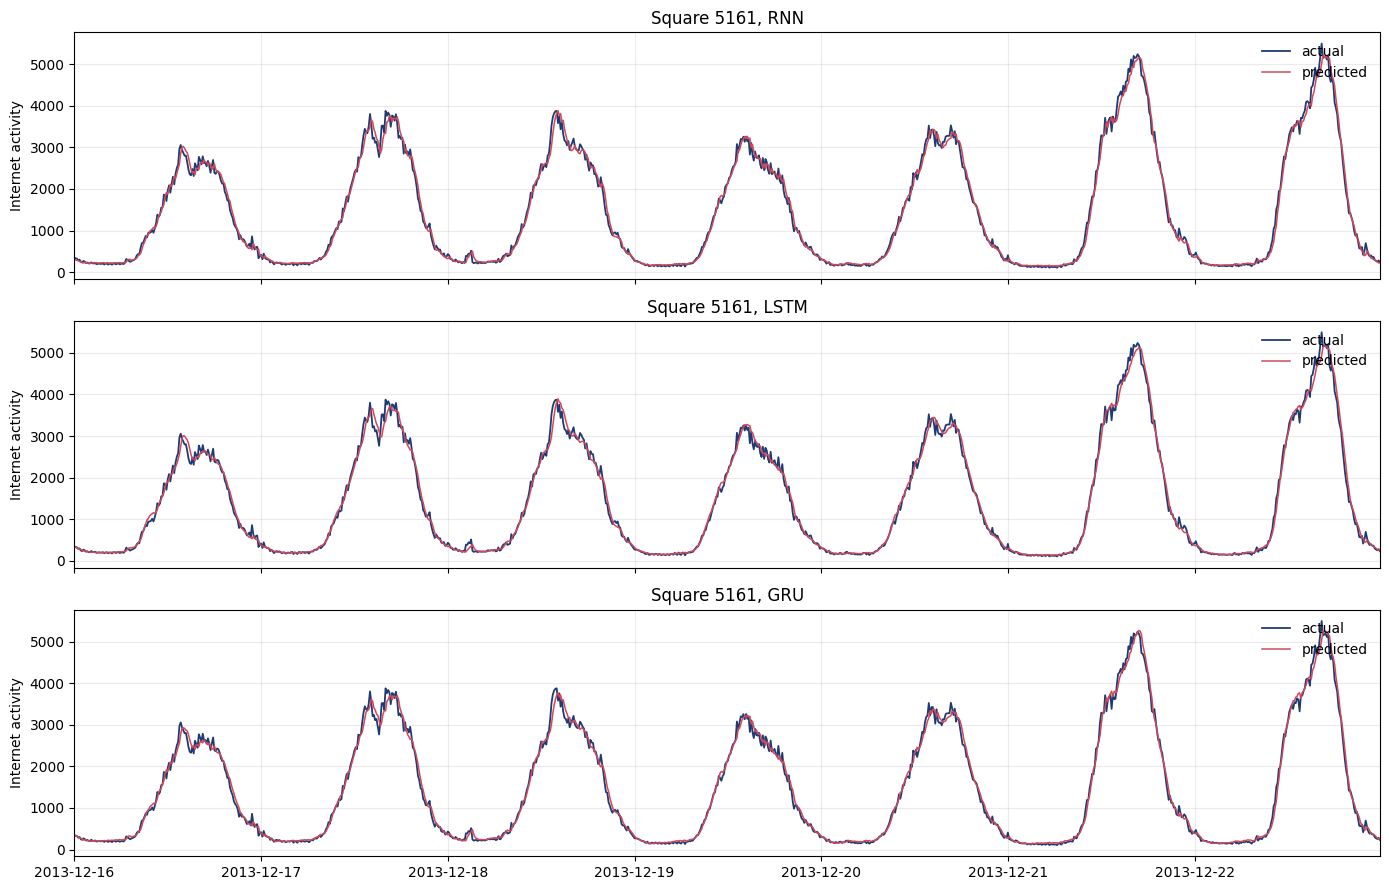

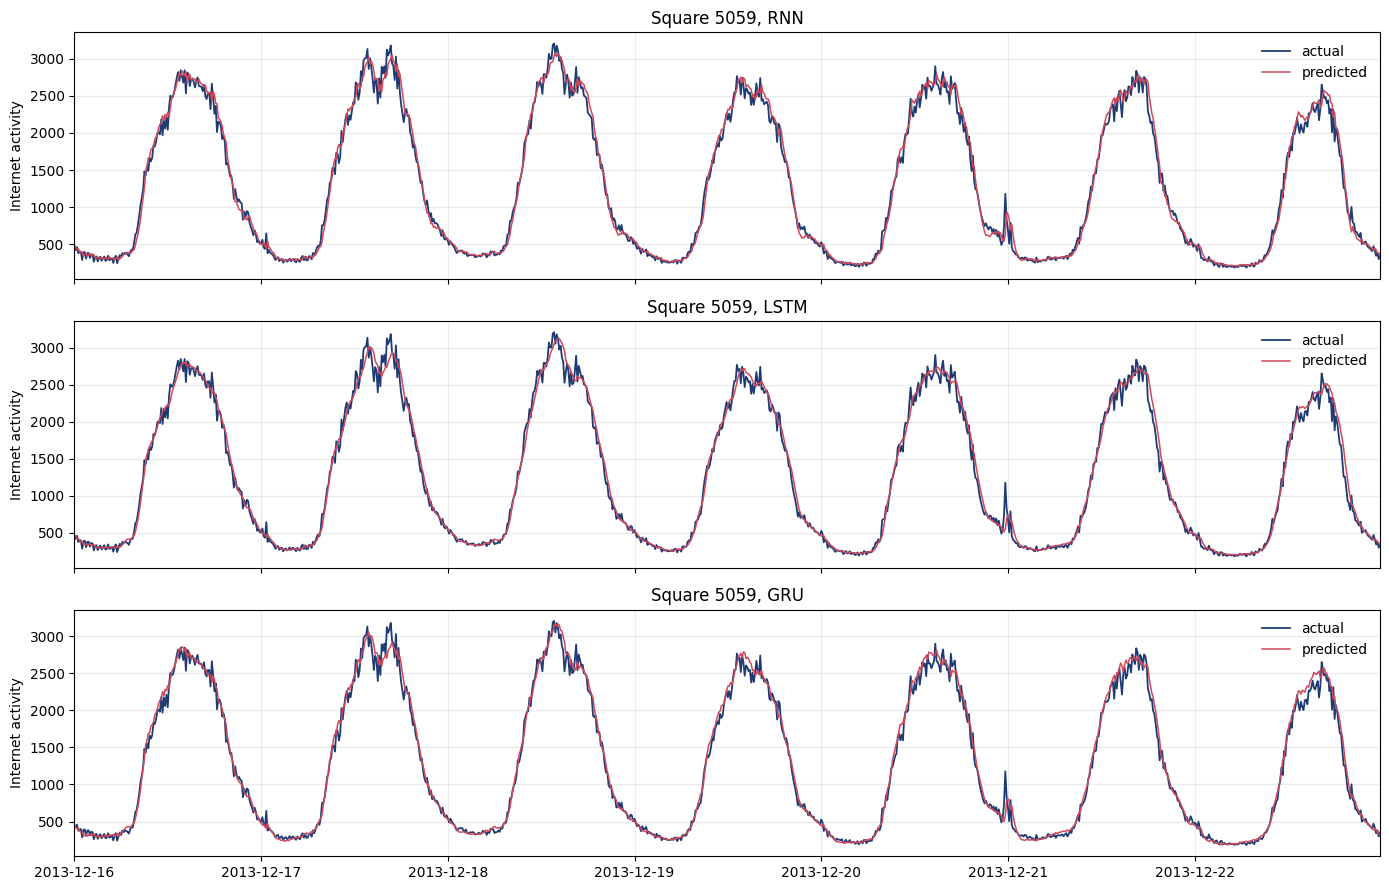

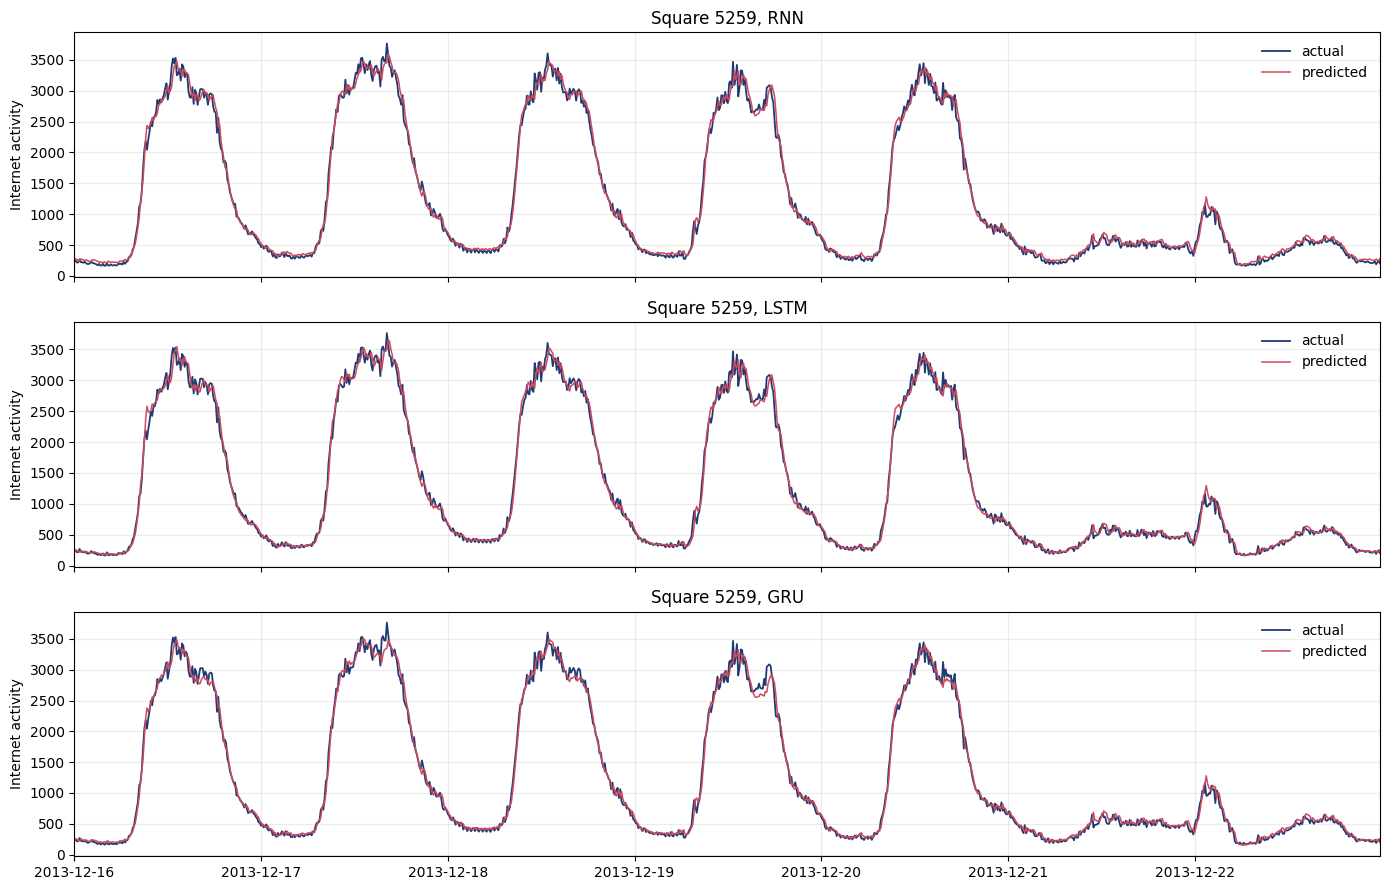

In [48]:
import matplotlib.pyplot as plt

# Make sure plots render in the notebook rather than to file.
%matplotlib inline

for square_id in squares:
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)


    for ax, architecture in zip(axes, ARCHITECTURES):
        prediction_key = f"square_id == {square_id} and model == '{architecture}'"

        subset = predictions.query(prediction_key).sort_values("timestamp")

        evaluate.plot_forecast(
            subset["timestamp"].to_numpy(),
            subset["actual"].to_numpy(),
            subset["predicted"].to_numpy(),
            f"Square {square_id}, {architecture}", ax
        )

    fig.tight_layout()

    plt.show()

## 7. Failure analysis

Where each model struggled, ranked by rolling mean absolute error over a one hour
window, then plotted around the single worst hour.

In [49]:
worst = []

all_architecture_models = ["RNN", "LSTM", "GRU", "Persistence", "SeasonalNaive"]

for square_id in squares:
    for model in all_architecture_models:
        prediction_key = f"square_id == {square_id} and model == '{model}'"

        subset = predictions.query(prediction_key).sort_values("timestamp")

        frame = evaluate.error_frame(
            pd.DatetimeIndex(subset["timestamp"]),
            subset["actual"].to_numpy(),
            subset["predicted"].to_numpy()
        )

        top = evaluate.worst_hours(frame, top=1)

        worst.append({
            "model": model,
            "square_id": square_id,
            "worst_hour_ending": top.index[0],
            "mean_error_over_hour": round(float(top["mean_error_over_hour"].iloc[0]), 2),
        })

pd.DataFrame(worst)

,model,square_id,worst_hour_ending,mean_error_over_hour
0,RNN,5161,2013-12-17 16:00:00+01:00,323.66
1,LSTM,5161,2013-12-17 16:00:00+01:00,324.80
2,GRU,5161,2013-12-18 14:00:00+01:00,337.82
3,Persistence,5161,2013-12-22 19:50:00+01:00,286.35
4,SeasonalNaive,5161,2013-12-16 16:30:00+01:00,2557.96
5,RNN,5059,2013-12-21 00:30:00+01:00,265.49
6,LSTM,5059,2013-12-22 19:50:00+01:00,270.47
7,GRU,5059,2013-12-17 16:40:00+01:00,237.51
8,Persistence,5059,2013-12-21 00:30:00+01:00,287.92
9,SeasonalNaive,5059,2013-12-16 09:50:00+01:00,886.04


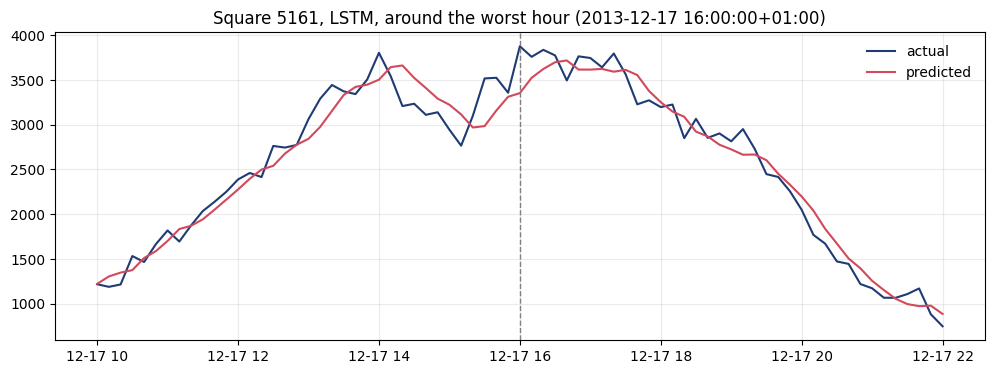

In [50]:
focus_square = squares[0]

prediction_key = f"square_id == {focus_square} and model == 'LSTM'"

subset = predictions.query(prediction_key).sort_values("timestamp")

frame = evaluate.error_frame(
    pd.DatetimeIndex(subset["timestamp"]),
    subset["actual"].to_numpy(),
    subset["predicted"].to_numpy()
)

worst_hour = evaluate.worst_hours(frame, top=1).index[0]

around = frame.loc[worst_hour - pd.Timedelta("6h"): worst_hour + pd.Timedelta("6h")]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(around.index, around["actual"], label="actual", color="#1f3b73")

ax.plot(around.index, around["predicted"], label="predicted", color="#d1495b")

ax.axvline(worst_hour, color="grey", linestyle="--", linewidth=1)

ax.set_title(f"Square {focus_square}, LSTM, around the worst hour ({worst_hour})")

ax.legend(frameon=False)

ax.grid(alpha=0.25)

plt.show()

### Did the models actually learn anything?

One-step-ahead prediction is deceptively easy on a smooth series.

We know there is a 0.987 correlation between the traffic series and lagged values ten minutes ago.

A model could get a good score even if it simply copies the last observation.

That is what the echo test measures - If a prediction is closer to the previous reading than the one being predicted, then the model is echoing rather than predicting.

In [51]:
import diagnostics

diagnostics.summarise(predictions, ["RNN", "LSTM", "GRU", "Persistence"])


,square_id,model,matches_previous_value,matches_the_target,correlation_with_previous,correlation_with_target,is_just_an_echo,mean_signed_error,while_traffic_rising,while_traffic_falling,share_over_predicted
0,5059,GRU,62.669998,70.160004,0.9964,0.9947,True,22.10,-26.52,68.45,0.56
1,5059,LSTM,52.139999,70.370003,0.9969,0.9941,True,13.00,-43.30,66.68,0.57
2,5059,Persistence,0.000000,81.540001,1.0000,0.9926,True,0.14,-83.36,79.76,0.51
3,5059,RNN,50.980000,74.959999,0.9975,0.9941,True,15.33,-45.75,73.56,0.57
4,5161,GRU,55.700001,83.459999,0.9984,0.9959,True,8.85,-60.31,78.56,0.58
5,5161,LSTM,61.730000,82.720001,0.9979,0.9957,True,3.68,-60.36,68.24,0.56
6,5161,Persistence,0.000000,92.889999,1.0000,0.9951,True,0.11,-92.32,93.29,0.50
7,5161,RNN,47.509998,86.000000,0.9988,0.9957,True,-2.59,-77.84,73.26,0.56
8,5259,GRU,45.680000,67.440002,0.9984,0.9965,True,6.80,-50.34,59.15,0.59
9,5259,LSTM,45.360001,67.529999,0.9980,0.9962,True,7.79,-48.42,59.31,0.54


Where in the day, and at what traffic levels, the errors land.


In [52]:
best_model = "LSTM"

busiest_square = squares[0]

prediction_key = f"square_id == {busiest_square} and model == '{best_model}'"

subset = predictions.query(prediction_key).sort_values("timestamp")

def frame_subset_assign_error(df: pd.DataFrame) -> pd.Series:
    return (df["actual"] - df["predicted"]).abs()

frame = subset.set_index("timestamp").assign(error=frame_subset_assign_error)

print(diagnostics.error_by_traffic_level(frame).to_string())

print("\n\n")

print(diagnostics.bias(frame).to_string())


      traffic_from  traffic_to  mean_error  error_as_percent
band                                                        
1            108.0       210.0   17.150000             10.10
2            210.0       471.0   32.439999             10.62
3            480.0      1472.0   79.930000              8.89
4           1495.0      2803.0  115.949997              5.22
5           2808.0      5496.0  167.639999              4.62



mean_signed_error         3.68
while_traffic_rising    -60.36
while_traffic_falling    68.24
share_over_predicted      0.56


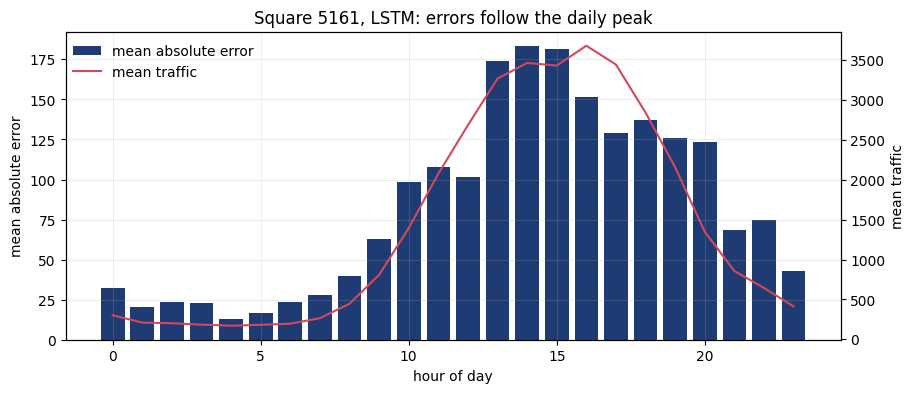

,mean_error,mean_actual,error_as_percent
hour,,,
0,32.160000,302.049988,10.65
1,20.459999,210.490005,9.72
2,23.650000,202.199997,11.70
3,22.799999,184.610001,12.35
4,13.170000,171.169998,7.70
5,16.809999,182.610001,9.21
6,23.549999,196.470001,11.98
7,27.990000,265.929993,10.53
8,39.599998,447.049988,8.86


In [53]:
hourly = diagnostics.error_by_hour(frame)

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(hourly.index, hourly["mean_error"], color="#1f3b73", label="mean absolute error")

ax.set_xlabel("hour of day")

ax.set_ylabel("mean absolute error")

twin = ax.twinx()

twin.plot(hourly.index, hourly["mean_actual"], color="#d1495b", label="mean traffic")

twin.set_ylabel("mean traffic")

ax.set_title(f"Square {squares[0]}, {best_model}: errors follow the daily peak")

ax.grid(alpha=0.2)

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88), frameon=False)

plt.show()

hourly

## 8. Save results

In [54]:
import shutil

# Results are written to the runtime rather than to Drive, so this notebook never needs access to anyone's account. The zip at the end is the thing to keep.

OUTPUT_DIRECTORY = pathlib.Path("/content/results")

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

(OUTPUT_DIRECTORY / "figures").mkdir(exist_ok=True)

all_runs.to_csv(OUTPUT_DIRECTORY / "tuning_all.csv", index=False)

seed_runs.to_csv(OUTPUT_DIRECTORY / "seed_runs.csv", index=False)

timings.to_csv(OUTPUT_DIRECTORY / "timings.csv", index=False)

predictions.to_parquet(OUTPUT_DIRECTORY / "predictions.parquet", index=False)

for square_id, table in metric_tables.items():
    table.to_csv(OUTPUT_DIRECTORY / f"metrics_{square_id}.csv")

(OUTPUT_DIRECTORY / "hardware.json").write_text(json.dumps(hardware, indent=2))

chosen_configs = json.dumps(
    {
        chosen_item: vars(chosen_item_config) for chosen_item, chosen_item_config in chosen.items()
    },
    indent=2,
)

(OUTPUT_DIRECTORY / "chosen_configs.json").write_text(chosen_configs)

for square_id in squares:
    for architecture in ARCHITECTURES:
        prediction_key = f"square_id == {square_id} and model == '{architecture}'"

        subset = predictions.query(prediction_key).sort_values("timestamp")

        fig, ax = plt.subplots(figsize=(13, 3.6))

        evaluate.plot_forecast(
            subset["timestamp"].to_numpy(),
            subset["actual"].to_numpy(),
            subset["predicted"].to_numpy(),
            f"Square {square_id}, {architecture}, 16 to 22 December", ax
        )

        fig.tight_layout()

        fig.savefig(OUTPUT_DIRECTORY / "figures" / f"forecast_{square_id}_{architecture}.png", dpi=150, bbox_inches="tight")

        plt.close(fig)

for name in sorted(p.name for p in config.FIGURE_DIRECTORY.glob("eda_*.png")):
    shutil.copy(config.FIGURE_DIRECTORY / name, OUTPUT_DIRECTORY / "figures" / name)

archive = shutil.make_archive("/content/milan_results", "zip", OUTPUT_DIRECTORY)

print(f"\nSaved {len(list(OUTPUT_DIRECTORY.rglob('*')))} files to {OUTPUT_DIRECTORY}")

print(f"\nZipped to {archive} ({pathlib.Path(archive).stat().st_size / 1e6:.1f} MB)")


Saved 26 files to /content/results

Zipped to /content/milan_results.zip (2.4 MB)


In [55]:
try:
    from google.colab import files

    files.download("/content/milan_results.zip")
except Exception as error:
    print("Not running in Colab, the zip is at /content/milan_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>